# Validation predictions

The three router outputs are produced on the same validation split. They are merged with `pid`, `is_CC`, `RunID`, and `EventID`. Routed predictions use the class selected by the classifier; oracle predictions use the truth-defined class.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd


validation_dir = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/"
    "102_string_emax1e6/inference_validation"
)
router_files = {
    "router1": validation_dir / "router1_predictions.csv",
    "router2": validation_dir / "router2_predictions.csv",
    "router3": validation_dir / "router3_predictions.csv",
}

missing_files = [str(path) for path in router_files.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Run the three inference-validation jobs first. Missing:\n  - "
        + "\n  - ".join(missing_files)
    )

id_columns = ["pid", "is_CC", "RunID", "EventID"]
truth_columns = ["totalEnergy", "true_log10_energy", "zenith", "azimuth"]
router_frames = {
    router_name: pd.read_csv(path)
    for router_name, path in router_files.items()
}

for router_name, frame in router_frames.items():
    if frame.duplicated(id_columns).any():
        raise ValueError(f"{router_name} has duplicate pid/is_CC/RunID/EventID combinations")

reference = router_frames["router1"]
router_comparison_df = reference[id_columns + truth_columns].copy()

for router_name, frame in router_frames.items():
    truth_check = router_comparison_df[id_columns + truth_columns].merge(
        frame[id_columns + truth_columns],
        on=id_columns,
        how="outer",
        suffixes=("_reference", f"_{router_name}"),
        indicator=True,
        validate="one_to_one",
    )
    if not truth_check["_merge"].eq("both").all():
        raise ValueError(f"{router_name} does not contain the same validation events")
    for column in truth_columns:
        if not np.allclose(
            truth_check[f"{column}_reference"],
            truth_check[f"{column}_{router_name}"],
            equal_nan=True,
        ):
            raise ValueError(f"Truth column {column} differs for {router_name}")

    router_columns = [
        column for column in frame.columns if column.startswith(f"{router_name}_")
    ]
    router_comparison_df = router_comparison_df.merge(
        frame[id_columns + router_columns],
        on=id_columns,
        how="inner",
        validate="one_to_one",
    )

print(f"Validation events: {len(router_comparison_df):,}")
print(f"Columns: {len(router_comparison_df.columns)}")
router_comparison_df.head()

Validation events: 42,944
Columns: 47


,pid,is_CC,RunID,EventID,totalEnergy,true_log10_energy,zenith,azimuth,router1_correct_class,router1_predicted_class,...,router3_p_class_0,router3_p_class_1,router3_routed_energy,router3_routed_log10_energy,router3_routed_zenith,router3_routed_azimuth,router3_oracle_energy,router3_oracle_log10_energy,router3_oracle_zenith,router3_oracle_azimuth
0,-16.0,1.0,1.0,112.0,155.109007,2.190637,0.814177,6.092665,0.0,0,...,0.924685,0.075315,239.20296,2.378766,1.108815,0.889331,239.20270,2.378766,1.108815,0.889331
1,-16.0,1.0,18.0,140.0,112.429879,2.050882,1.512533,4.892655,0.0,0,...,0.852312,0.147688,253.38057,2.403773,1.540377,5.786426,253.38057,2.403773,1.540377,5.786426
2,-16.0,1.0,19.0,116.0,2812.844874,3.449146,2.306260,5.834225,0.0,0,...,0.903873,0.096127,2596.59030,3.414403,2.442804,6.031103,2596.59030,3.414403,2.442804,6.031103
3,-16.0,1.0,23.0,167.0,125.191486,2.097575,1.325982,3.246784,0.0,0,...,0.889558,0.110442,179.00860,2.252874,1.209630,4.381919,179.00860,2.252874,1.209630,4.381919
4,-16.0,1.0,24.0,196.0,7726.045880,3.887957,1.584674,4.789152,0.0,0,...,0.796254,0.203746,5717.48500,3.757205,1.080480,4.865367,5717.48500,3.757205,1.080480,4.865367


# Comparison: Router 1 vs Router 2

## Tau energy reconstruction

Only truth-level Tau events are used. The curves show the median energy residual, $\log_{10}(E_{\mathrm{pred}}/E_{\mathrm{true}})$, and the shaded 16th to 84th percentile interval in bins of true energy. The left panel treats every validation event equally; the right panel uses `final_weight` from the Tau truth-level statistics.

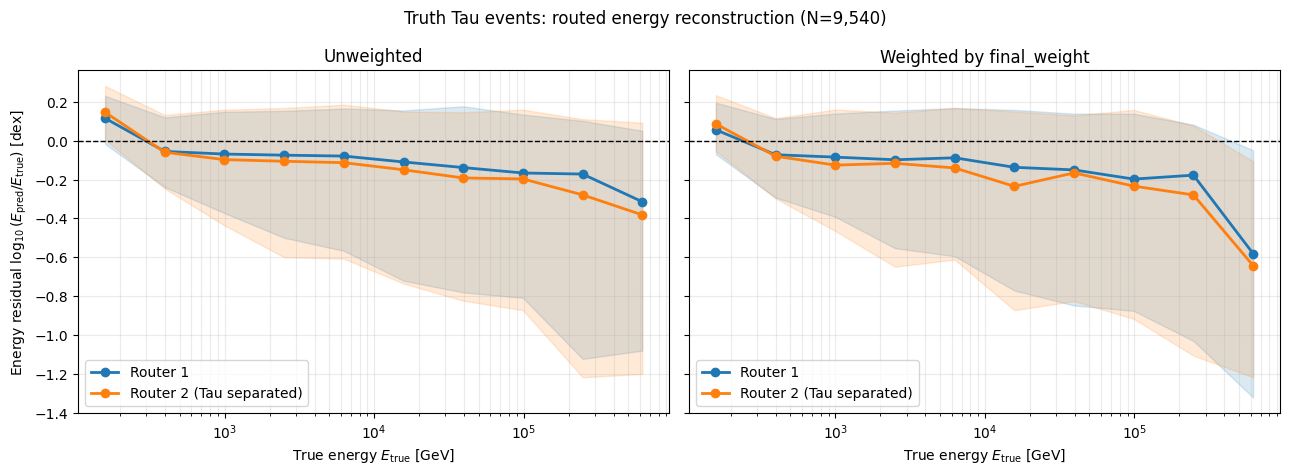

Tau validation events: 9,540


In [9]:
import matplotlib.pyplot as plt

weight_path = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Metadata/"
    "DatasetStatistics/TruthLevelStatistics/Tau.csv"
)
weight_columns = id_columns + ["final_weight"]
tau_weights = pd.read_csv(weight_path, usecols=weight_columns)

tau_df = router_comparison_df[router_comparison_df["pid"].abs() == 16].copy()
tau_df = tau_df.merge(
    tau_weights,
    on=id_columns,
    how="left",
    validate="one_to_one",
)
if tau_df["final_weight"].isna().any():
    raise ValueError("Some Tau validation events do not have final_weight")


def weighted_quantile(values, quantiles, weights):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.full(quantiles.shape, np.nan)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return np.interp(quantiles, cumulative, values)


energy_edges = np.logspace(
    np.log10(tau_df["totalEnergy"].min()),
    np.log10(tau_df["totalEnergy"].max()),
    11,
)
energy_centers = np.sqrt(energy_edges[:-1] * energy_edges[1:])
router_styles = {
    "router1": {"label": "Router 1", "color": "tab:blue"},
    "router2": {"label": "Router 2 (Tau separated)", "color": "tab:orange"},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
for ax, use_event_weight in zip(axes, [False, True]):
    for router_name, style in router_styles.items():
        residual = (
            tau_df[f"{router_name}_routed_log10_energy"]
            - tau_df["true_log10_energy"]
        )
        medians, lower, upper = [], [], []
        for low, high in zip(energy_edges[:-1], energy_edges[1:]):
            in_bin = tau_df["totalEnergy"].between(low, high, inclusive="left")
            values = residual[in_bin].to_numpy()
            if use_event_weight:
                summary = weighted_quantile(
                    values,
                    [0.16, 0.50, 0.84],
                    tau_df.loc[in_bin, "final_weight"].to_numpy(),
                )
            else:
                values = values[np.isfinite(values)]
                summary = (
                    np.quantile(values, [0.16, 0.50, 0.84])
                    if values.size
                    else np.full(3, np.nan)
                )
            lower.append(summary[0])
            medians.append(summary[1])
            upper.append(summary[2])

        medians = np.asarray(medians)
        lower = np.asarray(lower)
        upper = np.asarray(upper)
        ax.plot(
            energy_centers,
            medians,
            marker="o",
            linewidth=2,
            color=style["color"],
            label=style["label"],
        )
        ax.fill_between(
            energy_centers,
            lower,
            upper,
            color=style["color"],
            alpha=0.16,
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]")
    ax.set_title("Weighted by final_weight" if use_event_weight else "Unweighted")
    ax.grid(True, alpha=0.25, which="both")
    ax.legend()

axes[0].set_ylabel(r"Energy residual $\log_{10}(E_{\mathrm{pred}}/E_{\mathrm{true}})$ [dex]")
fig.suptitle(f"Truth Tau events: routed energy reconstruction (N={len(tau_df):,})")
fig.tight_layout()
plt.show()

print(f"Tau validation events: {len(tau_df):,}")

## Tau energy reconstruction by Router 2 predicted route

Truth-level Tau events are divided into three mutually exclusive groups using Router 2\u0027s predicted class. Each row uses the same fixed event group: the left panel is unweighted and the right panel uses `final_weight`. Router 1 and Router 2 are compared directly. Solid curves show the median residual and shaded regions show the 16th to 84th percentile interval.

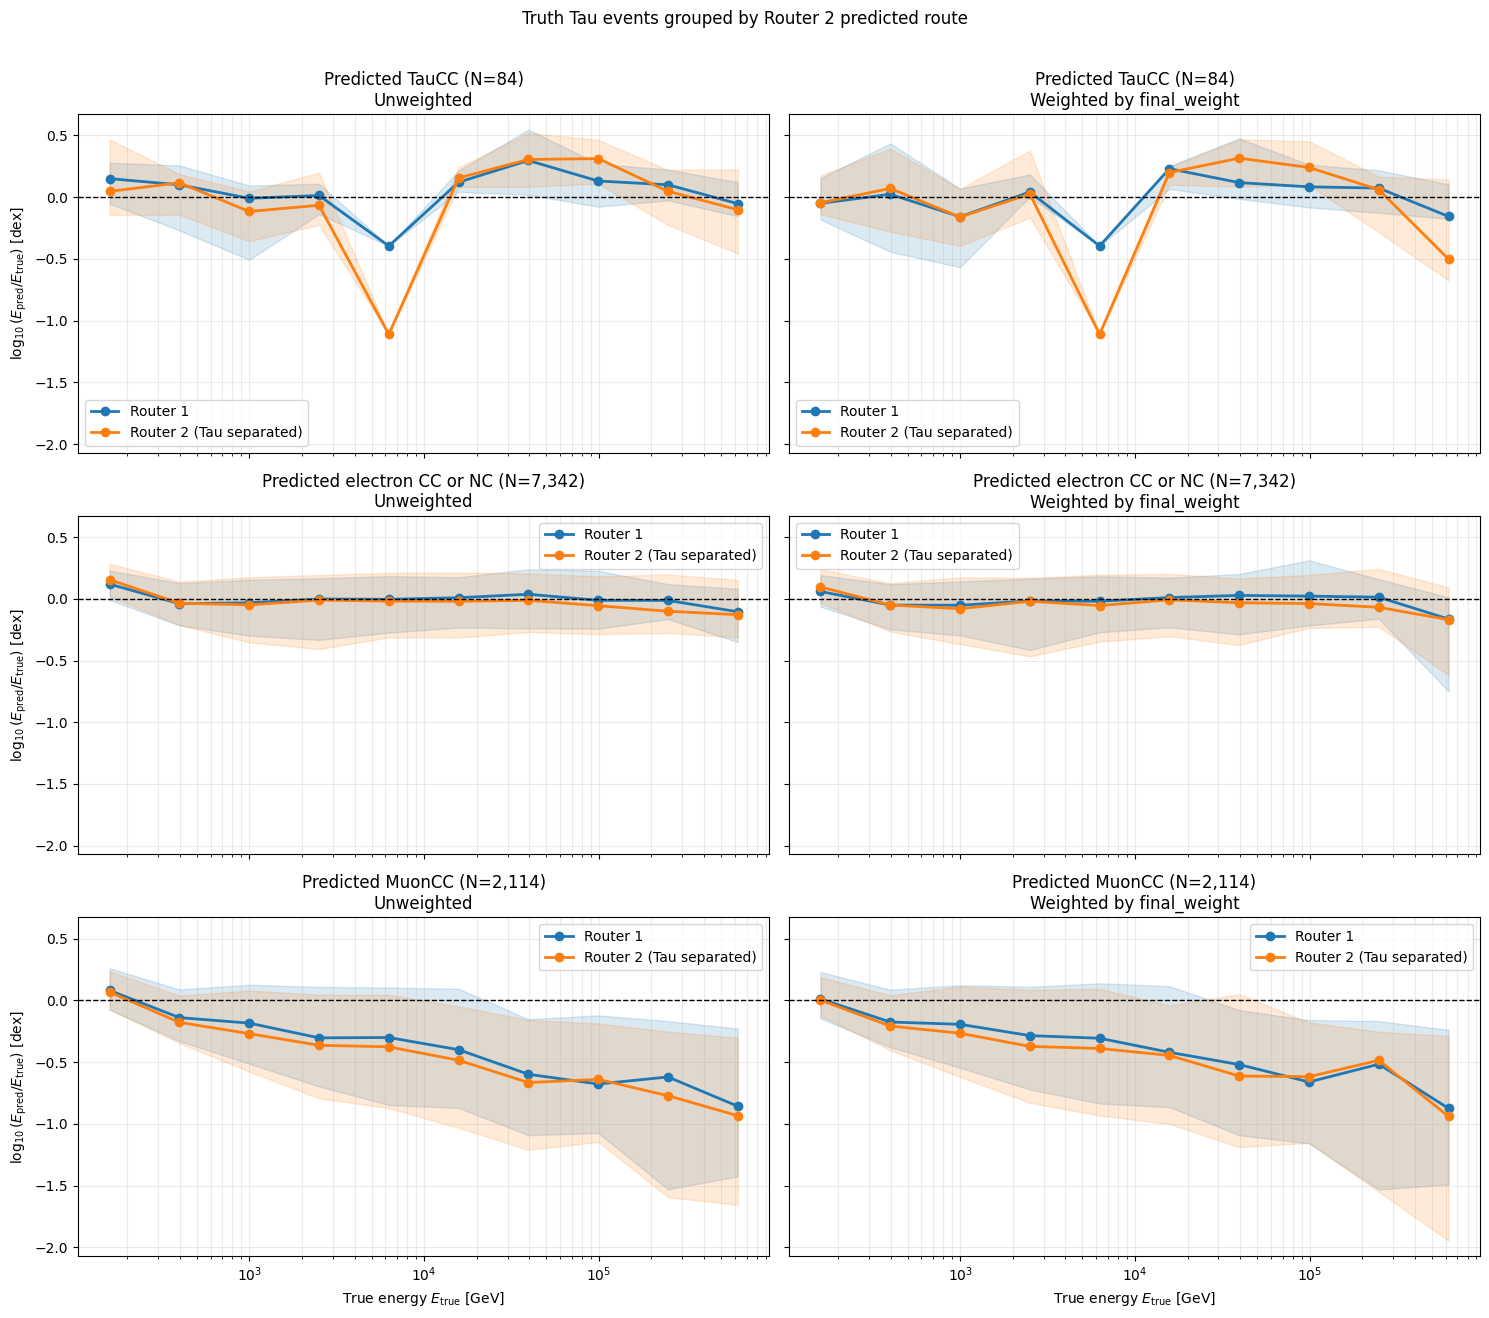

In [10]:
router2_route_names = {
    0: "Predicted TauCC",
    1: "Predicted electron CC or NC",
    2: "Predicted MuonCC",
}

fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True, sharey=True)
for row, (predicted_class, route_name) in enumerate(router2_route_names.items()):
    route_mask = tau_df["router2_predicted_class"].astype(int) == predicted_class
    route_df = tau_df.loc[route_mask]

    for column, use_event_weight in enumerate([False, True]):
        ax = axes[row, column]
        for router_name, style in router_styles.items():
            residual = (
                route_df[f"{router_name}_routed_log10_energy"]
                - route_df["true_log10_energy"]
            )
            medians, lower, upper = [], [], []
            for low, high in zip(energy_edges[:-1], energy_edges[1:]):
                in_bin = route_df["totalEnergy"].between(low, high, inclusive="left")
                values = residual[in_bin].to_numpy()
                if use_event_weight:
                    summary = weighted_quantile(
                        values,
                        [0.16, 0.50, 0.84],
                        route_df.loc[in_bin, "final_weight"].to_numpy(),
                    )
                else:
                    values = values[np.isfinite(values)]
                    summary = (
                        np.quantile(values, [0.16, 0.50, 0.84])
                        if values.size
                        else np.full(3, np.nan)
                    )
                lower.append(summary[0])
                medians.append(summary[1])
                upper.append(summary[2])

            medians = np.asarray(medians)
            lower = np.asarray(lower)
            upper = np.asarray(upper)
            ax.plot(
                energy_centers,
                medians,
                marker="o",
                linewidth=2,
                color=style["color"],
                label=style["label"],
            )
            ax.fill_between(
                energy_centers,
                lower,
                upper,
                color=style["color"],
                alpha=0.16,
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_title(
            f"{route_name} (N={len(route_df):,})\n"
            + ("Weighted by final_weight" if use_event_weight else "Unweighted")
        )
        ax.grid(True, alpha=0.25, which="both")
        ax.legend()

    axes[row, 0].set_ylabel(
        r"$\log_{10}(E_{\mathrm{pred}}/E_{\mathrm{true}})$ [dex]"
    )

for ax in axes[-1, :]:
    ax.set_xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]")

fig.suptitle("Truth Tau events grouped by Router 2 predicted route", y=1.01)
fig.tight_layout()
plt.show()

## Tau direction reconstruction by Router 2 predicted route

Truth-level Tau events are grouped by Router 2\u0027s predicted class. For each fixed event group, Router 1 and Router 2 are compared in a 3 by 2 layout: unweighted on the left and weighted by `final_weight` on the right. Azimuth residuals are wrapped to $[-180^\circ, 180^\circ]$.

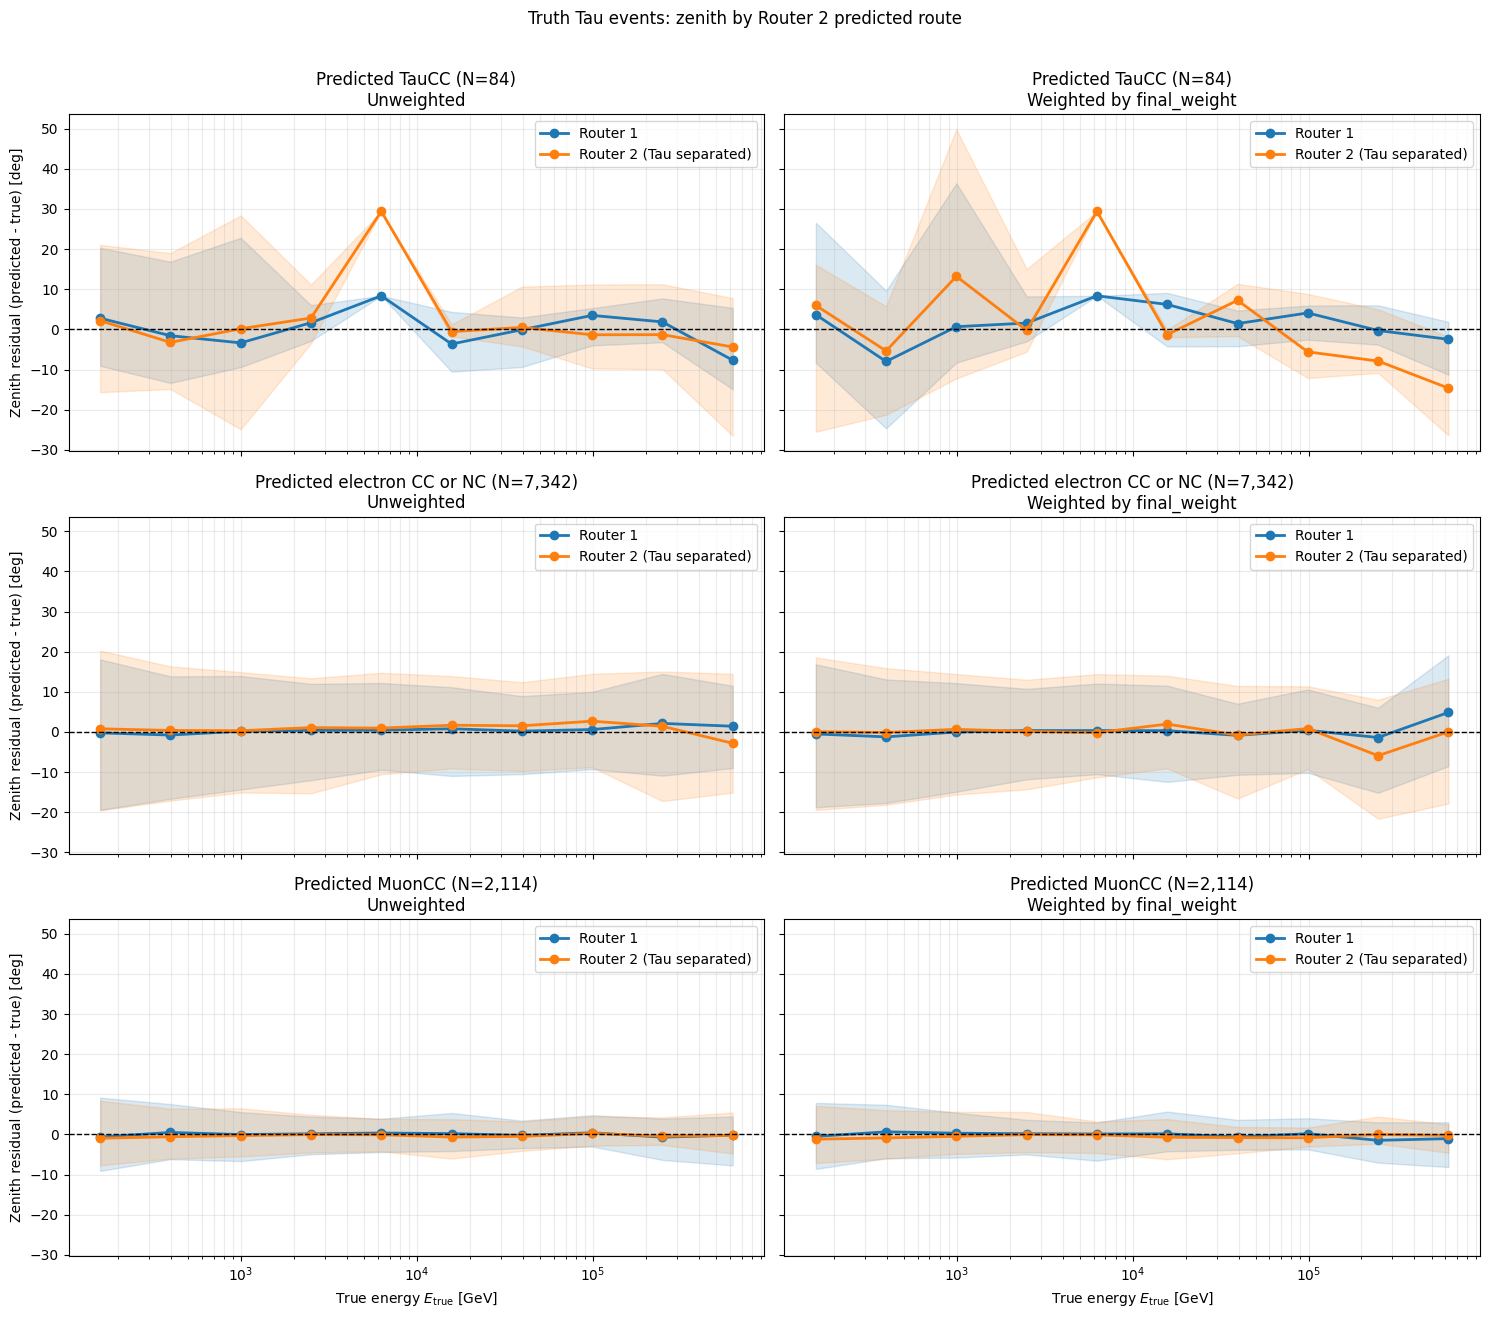

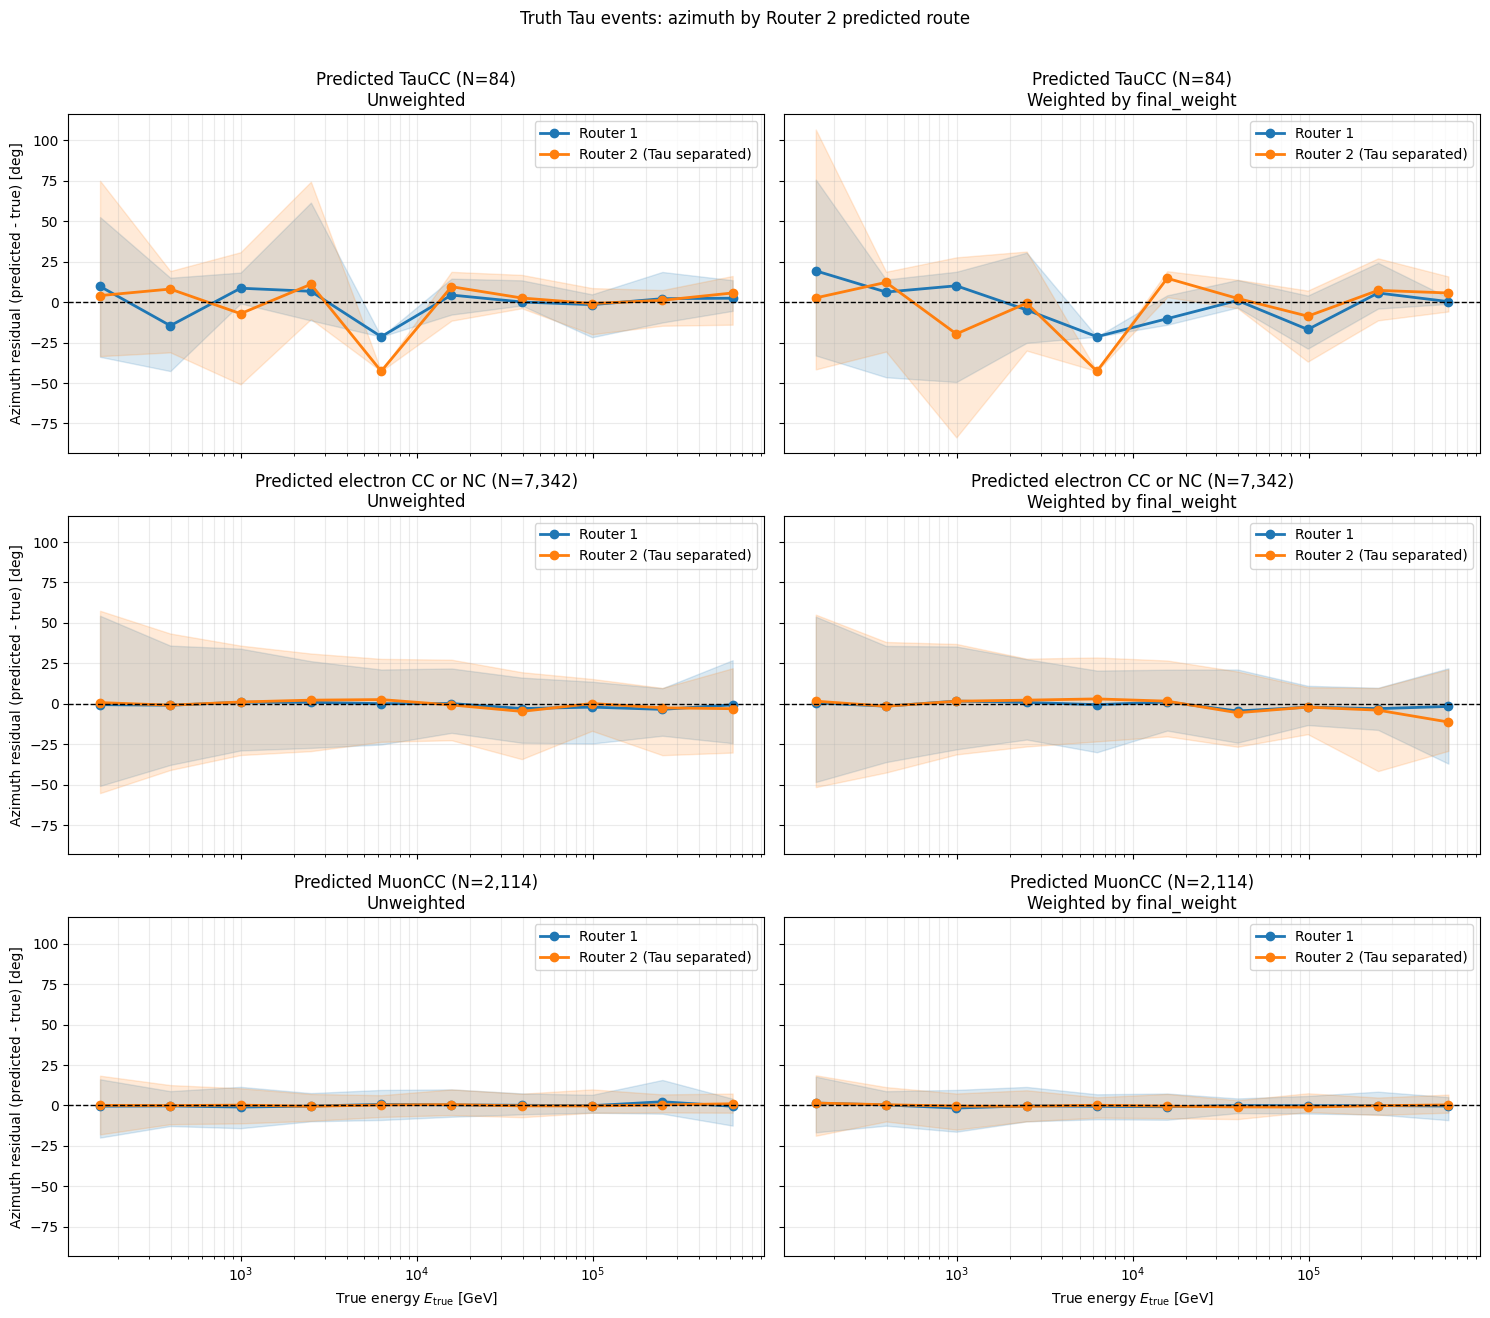

In [11]:
def plot_tau_angular_residual_by_router2_route(variable, circular=False):
    fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True, sharey=True)

    for row, (predicted_class, route_name) in enumerate(router2_route_names.items()):
        route_mask = tau_df["router2_predicted_class"].astype(int) == predicted_class
        route_df = tau_df.loc[route_mask]

        for column, use_event_weight in enumerate([False, True]):
            ax = axes[row, column]
            for router_name, style in router_styles.items():
                delta = (
                    route_df[f"{router_name}_routed_{variable}"]
                    - route_df[variable]
                )
                if circular:
                    delta = np.arctan2(np.sin(delta), np.cos(delta))
                residual = np.degrees(delta)

                medians, lower, upper = [], [], []
                for low, high in zip(energy_edges[:-1], energy_edges[1:]):
                    in_bin = route_df["totalEnergy"].between(
                        low, high, inclusive="left"
                    )
                    values = residual[in_bin].to_numpy()
                    if use_event_weight:
                        summary = weighted_quantile(
                            values,
                            [0.16, 0.50, 0.84],
                            route_df.loc[in_bin, "final_weight"].to_numpy(),
                        )
                    else:
                        values = values[np.isfinite(values)]
                        summary = (
                            np.quantile(values, [0.16, 0.50, 0.84])
                            if values.size
                            else np.full(3, np.nan)
                        )
                    lower.append(summary[0])
                    medians.append(summary[1])
                    upper.append(summary[2])

                medians = np.asarray(medians)
                lower = np.asarray(lower)
                upper = np.asarray(upper)
                ax.plot(
                    energy_centers,
                    medians,
                    marker="o",
                    linewidth=2,
                    color=style["color"],
                    label=style["label"],
                )
                ax.fill_between(
                    energy_centers,
                    lower,
                    upper,
                    color=style["color"],
                    alpha=0.16,
                )

            ax.axhline(0, color="black", linestyle="--", linewidth=1)
            ax.set_xscale("log")
            ax.set_title(
                f"{route_name} (N={len(route_df):,})\n"
                + ("Weighted by final_weight" if use_event_weight else "Unweighted")
            )
            ax.grid(True, alpha=0.25, which="both")
            ax.legend()

        axes[row, 0].set_ylabel(
            f"{variable.capitalize()} residual (predicted - true) [deg]"
        )

    for ax in axes[-1, :]:
        ax.set_xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]")

    fig.suptitle(
        f"Truth Tau events: {variable} by Router 2 predicted route",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


plot_tau_angular_residual_by_router2_route("zenith")
plot_tau_angular_residual_by_router2_route("azimuth", circular=True)

## Tau direction reconstruction

Zenith and azimuth residuals are shown in degrees using the same Tau events and true-energy bins. The azimuth difference is wrapped to $[-180^\circ, 180^\circ]$ so that the periodic boundary is handled correctly.

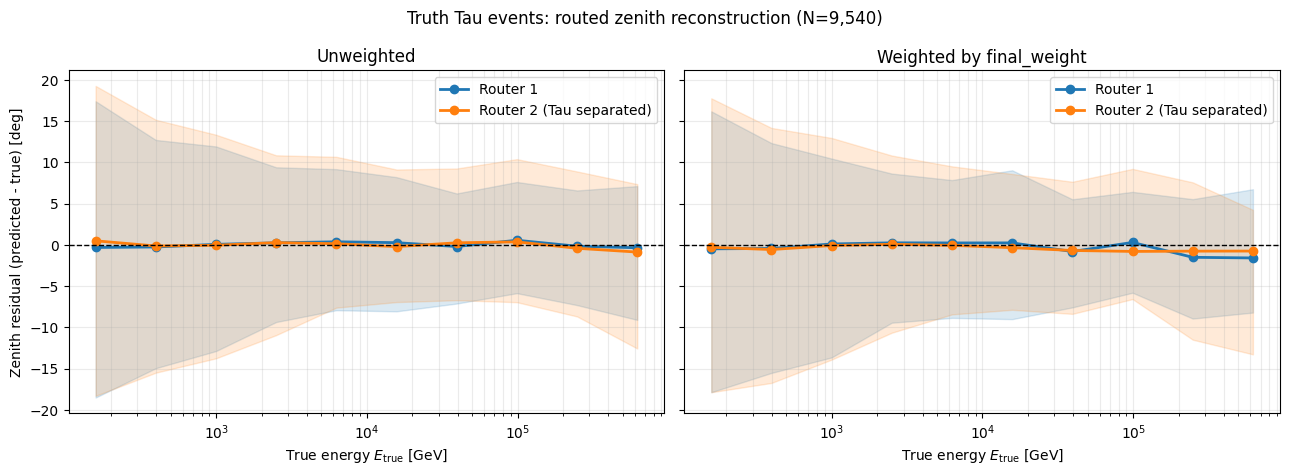

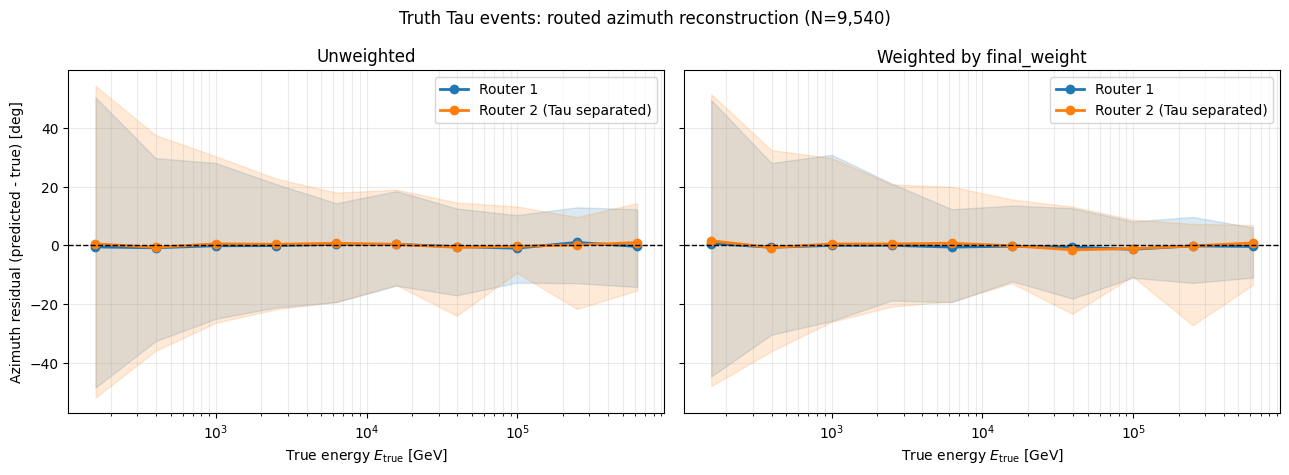

In [12]:
def plot_tau_angular_residual(variable, circular=False):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)

    for ax, use_event_weight in zip(axes, [False, True]):
        for router_name, style in router_styles.items():
            delta = tau_df[f"{router_name}_routed_{variable}"] - tau_df[variable]
            if circular:
                delta = np.arctan2(np.sin(delta), np.cos(delta))
            residual = np.degrees(delta)

            medians, lower, upper = [], [], []
            for low, high in zip(energy_edges[:-1], energy_edges[1:]):
                in_bin = tau_df["totalEnergy"].between(low, high, inclusive="left")
                values = residual[in_bin].to_numpy()
                if use_event_weight:
                    summary = weighted_quantile(
                        values,
                        [0.16, 0.50, 0.84],
                        tau_df.loc[in_bin, "final_weight"].to_numpy(),
                    )
                else:
                    values = values[np.isfinite(values)]
                    summary = (
                        np.quantile(values, [0.16, 0.50, 0.84])
                        if values.size
                        else np.full(3, np.nan)
                    )
                lower.append(summary[0])
                medians.append(summary[1])
                upper.append(summary[2])

            medians = np.asarray(medians)
            lower = np.asarray(lower)
            upper = np.asarray(upper)
            ax.plot(
                energy_centers,
                medians,
                marker="o",
                linewidth=2,
                color=style["color"],
                label=style["label"],
            )
            ax.fill_between(
                energy_centers,
                lower,
                upper,
                color=style["color"],
                alpha=0.16,
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_xlabel(r"True energy $E_{\mathrm{true}}$ [GeV]")
        ax.set_title("Weighted by final_weight" if use_event_weight else "Unweighted")
        ax.grid(True, alpha=0.25, which="both")
        ax.legend()

    display_name = variable.capitalize()
    axes[0].set_ylabel(f"{display_name} residual (predicted - true) [deg]")
    fig.suptitle(
        f"Truth Tau events: routed {variable} reconstruction (N={len(tau_df):,})"
    )
    fig.tight_layout()
    plt.show()


plot_tau_angular_residual("zenith")
plot_tau_angular_residual("azimuth", circular=True)